In [1]:
import pandas as pd

# ---------------------------------------------------------
# Load Dataset
# ---------------------------------------------------------
# This file contains the integrated dataset including:
# - Polygenic Risk Scores (PGS)
# - Metabolomics features
# - Metabolic reaction flux features
# - Pathway-level flux features
# - Clinical metadata including diagnosis

merged_df_with_diagnosis = pd.read_csv("merged_data.csv")

In [2]:
# Display the distribution of diagnosis labels
diagnosis_counts = merged_df_with_diagnosis['Diagnosis'].value_counts()

print("Diagnosis distribution:")
print(diagnosis_counts)

Diagnosis distribution:
Diagnosis
AD         141
Control    118
Name: count, dtype: int64


In [3]:
# Filter only AD and Control diagnoses
filtered_df = merged_df_with_diagnosis[merged_df_with_diagnosis['Diagnosis'].isin(['AD', 'Control'])]

# Separate features and labels
X = filtered_df.drop(columns=['sample_id', 'Diagnosis'])
y = filtered_df['Diagnosis'].map({'AD': 1, 'Control': 0})  # Binary classification

# Scaling and train/test split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

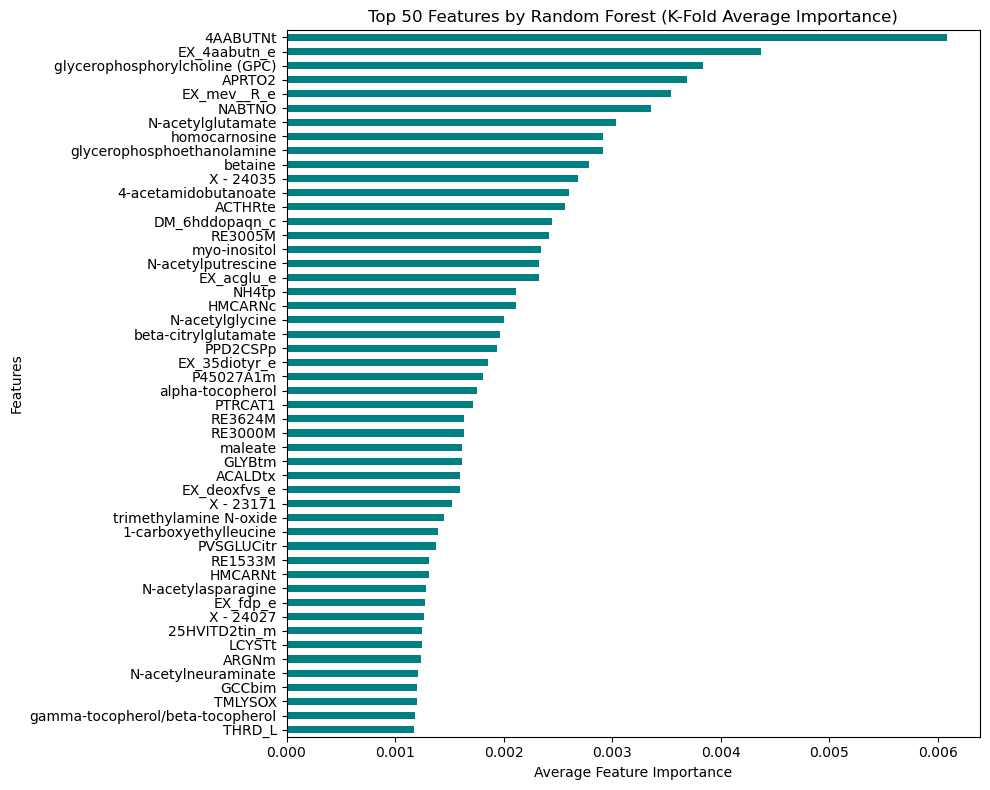

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

# ---------------------------------------------------------
# 1. K-Fold Setup
# ---------------------------------------------------------
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---------------------------------------------------------
# 2. Initialize list to store feature importances for each fold
# ---------------------------------------------------------
feature_importances = []

# ---------------------------------------------------------
# 3. Train Random Forest on each fold and collect feature importances
# ---------------------------------------------------------
for train_index, test_index in kf.split(X_train_scaled, y_train):
    X_fold_train = X_train_scaled[train_index]
    y_fold_train = y_train.iloc[train_index]

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_fold_train, y_fold_train)

    feature_importances.append(rf.feature_importances_)

# ---------------------------------------------------------
# 4. Compute average feature importance across folds
# ---------------------------------------------------------
avg_importances = np.mean(feature_importances, axis=0)

# Convert to pandas Series and sort descending
feat_importances = pd.Series(avg_importances, index=X.columns).sort_values(ascending=False)

# ---------------------------------------------------------
# 5. Visualize top 50 features
# ---------------------------------------------------------
top_n = 50
plt.figure(figsize=(10, 8))
feat_importances.head(top_n).plot(
    kind='barh',
    color='teal'
)
plt.title(f"Top {top_n} Features by Random Forest (K-Fold Average Importance)")
plt.xlabel("Average Feature Importance")
plt.ylabel("Features")
plt.gca().invert_yaxis()  # Highest importance on top
plt.tight_layout()
plt.show()

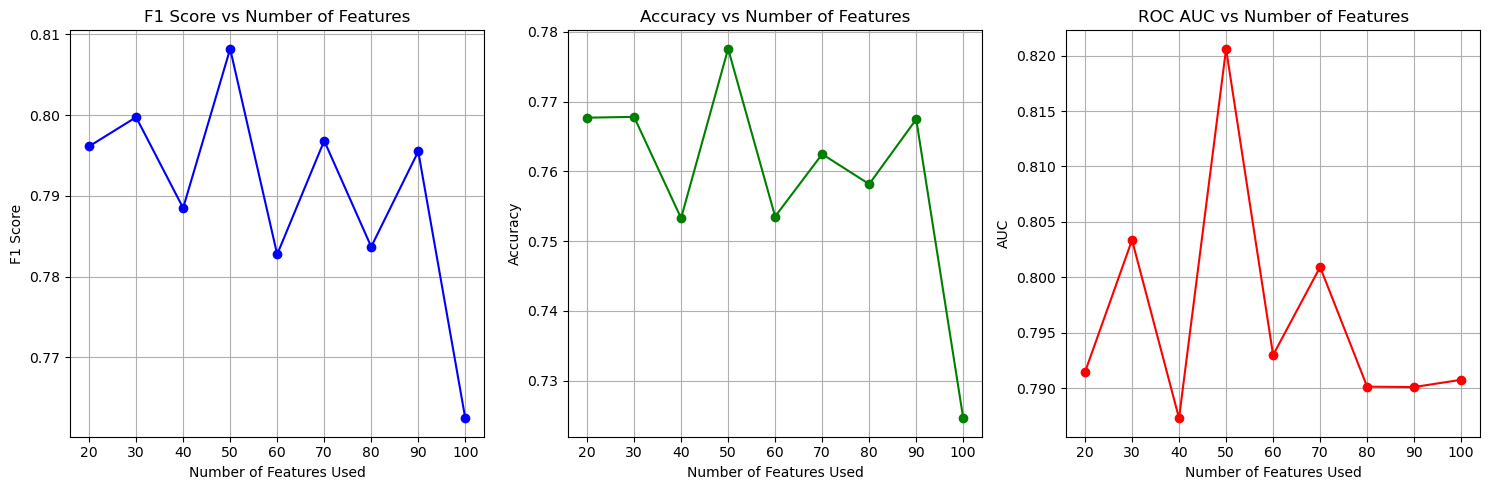

In [5]:
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Initialize lists to store scores
# ---------------------------------------------------------
f1_scores = []
accuracy_scores = []
auc_scores = []

# Feature counts to test (20 to 100 in steps of 10)
feature_counts = list(range(20, 101, 10))

# ---------------------------------------------------------
# 2. Train models with increasing number of top features
# ---------------------------------------------------------
for n_features in feature_counts:
    # Select top n_features based on previous Random Forest importance ranking
    selected_features = list(feat_importances.head(n_features).index)
    selected_indices = [X.columns.get_loc(f) for f in selected_features]
    X_selected = X_train_scaled[:, selected_indices]

    fold_f1 = []
    fold_accuracy = []
    fold_auc = []

    # K-Fold cross-validation
    for train_index, test_index in kf.split(X_selected, y_train):
        X_fold_train = X_selected[train_index]
        y_fold_train = y_train.iloc[train_index]
        X_fold_test = X_selected[test_index]
        y_fold_test = y_train.iloc[test_index]

        rf = RandomForestClassifier(n_estimators=100, random_state=42)
        rf.fit(X_fold_train, y_fold_train)

        y_pred = rf.predict(X_fold_test)
        y_pred_prob = rf.predict_proba(X_fold_test)[:, 1]

        fold_f1.append(f1_score(y_fold_test, y_pred))
        fold_accuracy.append(accuracy_score(y_fold_test, y_pred))
        fold_auc.append(roc_auc_score(y_fold_test, y_pred_prob))

    # Average across folds
    f1_scores.append(np.mean(fold_f1))
    accuracy_scores.append(np.mean(fold_accuracy))
    auc_scores.append(np.mean(fold_auc))

# ---------------------------------------------------------
# 3. Visualize results
# ---------------------------------------------------------
plt.figure(figsize=(15, 5))

# F1 Score
plt.subplot(1, 3, 1)
plt.plot(feature_counts, f1_scores, marker='o', color='blue')
plt.title('F1 Score vs Number of Features')
plt.xlabel('Number of Features Used')
plt.ylabel('F1 Score')
plt.grid(True)

# Accuracy
plt.subplot(1, 3, 2)
plt.plot(feature_counts, accuracy_scores, marker='o', color='green')
plt.title('Accuracy vs Number of Features')
plt.xlabel('Number of Features Used')
plt.ylabel('Accuracy')
plt.grid(True)

# AUC
plt.subplot(1, 3, 3)
plt.plot(feature_counts, auc_scores, marker='o', color='red')
plt.title('ROC AUC vs Number of Features')
plt.xlabel('Number of Features Used')
plt.ylabel('AUC')
plt.grid(True)

plt.tight_layout()
plt.show()

In [6]:
# ---------------------------------------------------------
# 1. Identify the best scores and corresponding number of features
# ---------------------------------------------------------
best_f1 = max(f1_scores)
best_f1_features = feature_counts[f1_scores.index(best_f1)]

best_acc = max(accuracy_scores)
best_acc_features = feature_counts[accuracy_scores.index(best_acc)]

best_auc = max(auc_scores)
best_auc_features = feature_counts[auc_scores.index(best_auc)]

# ---------------------------------------------------------
# 2. Print results
# ---------------------------------------------------------
print(f"Highest F1 Score: {best_f1:.4f} (Number of Features: {best_f1_features})")
print(f"Highest Accuracy: {best_acc:.4f} (Number of Features: {best_acc_features})")
print(f"Highest ROC AUC: {best_auc:.4f} (Number of Features: {best_auc_features})")

Highest F1 Score: 0.8082 (Number of Features: 50)
Highest Accuracy: 0.7776 (Number of Features: 50)
Highest ROC AUC: 0.8206 (Number of Features: 50)


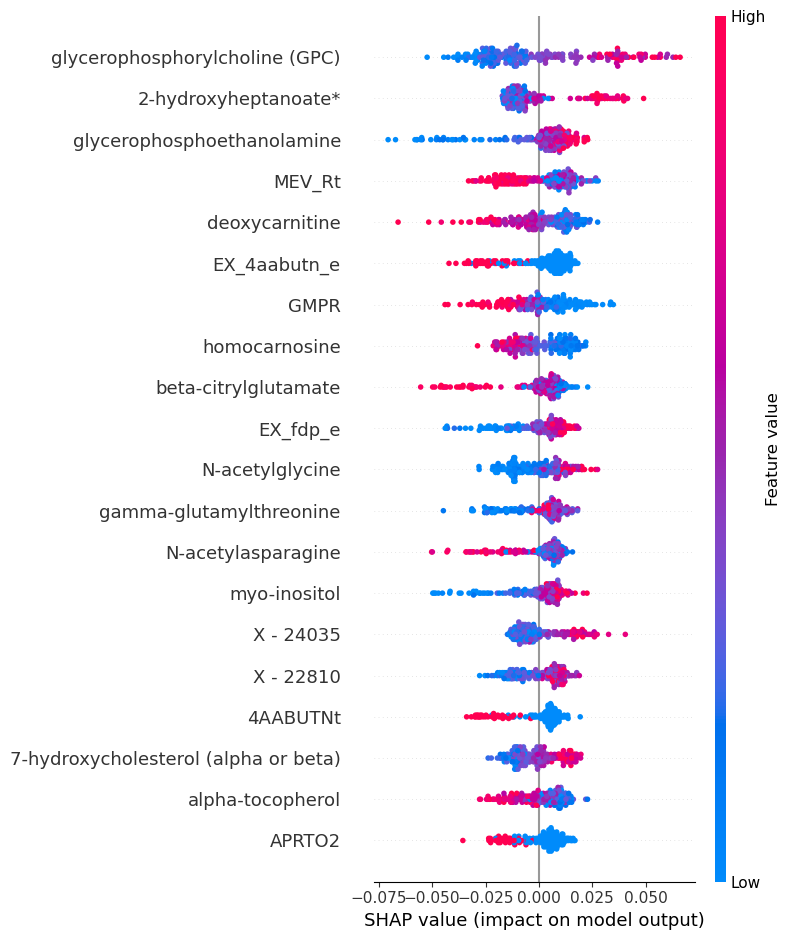

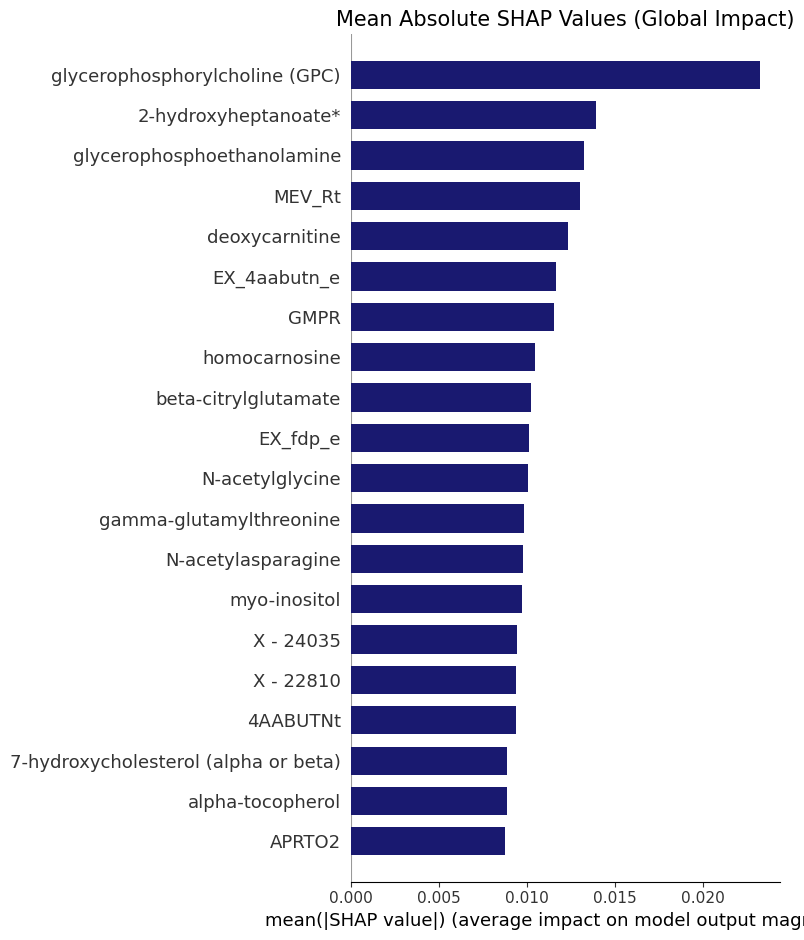


SHAP STRATEGIC FEATURE ANALYSIS REPORT
                  Feature_Name  Average_Impact_Score
glycerophosphorylcholine (GPC)              0.023191
          2-hydroxyheptanoate*              0.013907
    glycerophosphoethanolamine              0.013253
                        MEV_Rt              0.012997
                deoxycarnitine              0.012302
                  EX_4aabutn_e              0.011671
                          GMPR              0.011514
                 homocarnosine              0.010441
          beta-citrylglutamate              0.010227
                      EX_fdp_e              0.010125
               N-acetylglycine              0.010040
       gamma-glutamylthreonine              0.009807
            N-acetylasparagine              0.009785
                  myo-inositol              0.009709
                     X - 24035              0.009447
Graphs saved as 'shap_summary_impact.png' and 'shap_feature_importance.png'


In [7]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Veri ve Model Hazırlığı (Hata almamak için veriyi DataFrame'e çeviriyoruz)
X_shap_df = pd.DataFrame(X_train_scaled[:, selected_indices], columns=selected_features)

# Modeli eğit
rf_shap = RandomForestClassifier(n_estimators=100, random_state=42)
rf_shap.fit(X_shap_df, y_train)

# 2. SHAP Değerlerini Hesapla
explainer = shap.TreeExplainer(rf_shap)
shap_results = explainer.shap_values(X_shap_df)

# HATA ÇÖZÜMÜ: Boyut kontrolü ve düzeltme
# Eğer sonuç 3 boyutluysa veya listeyse, pozitif sınıfın (indeks 1) değerlerini alıyoruz
if isinstance(shap_results, list):
    actual_shap_values = shap_results[1]
elif len(shap_results.shape) == 3:
    actual_shap_values = shap_results[:, :, 1]
else:
    actual_shap_values = shap_results

# 3. GÖRSELLEŞTİRME (İngilizce Grafikler)

# A. Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(actual_shap_values, X_shap_df, show=False)
plt.title("", fontsize=15)
plt.tight_layout()
plt.savefig('shap_summary_impact.png', dpi=300)
plt.show()

# B. Global Importance Bar Chart
plt.figure(figsize=(12, 8))
shap.summary_plot(actual_shap_values, X_shap_df, plot_type="bar", show=False, color='midnightblue')
plt.title("Mean Absolute SHAP Values (Global Impact)", fontsize=15)
plt.tight_layout()
plt.savefig('shap_feature_importance.png', dpi=300)
plt.show()

# 4. YAZILI RAPOR (Hatanın düzeltildiği kısım)
# np.abs(...).mean(axis=0) ile her özelliğin ortalama etkisini tek boyuta indiriyoruz
mean_shap_importance = np.abs(actual_shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    'Feature_Name': selected_features,
    'Average_Impact_Score': mean_shap_importance
}).sort_values(by='Average_Impact_Score', ascending=False)

print("\n" + "="*45)
print("SHAP STRATEGIC FEATURE ANALYSIS REPORT")
print("="*45)
print(importance_df.head(15).to_string(index=False))
print("="*45)
print("Graphs saved as 'shap_summary_impact.png' and 'shap_feature_importance.png'")

In [8]:
import pandas as pd
import numpy as np
from scipy import stats

# --- SECTION 1: WELCH'S T-TEST (METABOLITE ANALYSIS) ---
# Use top 15 features from SHAP impact
top_features = importance_df.head(15)['Feature_Name'].tolist()

group_0_data = X_shap_df[y_train.values == 0]
group_1_data = X_shap_df[y_train.values == 1]

ttest_results = []
for feat in top_features:
    # Independent t-test (Welch's t-test: unequal variances assumed)
    t_stat, p_val = stats.ttest_ind(group_1_data[feat], group_0_data[feat], equal_var=False)
    
    ttest_results.append({
        'Feature': feat,
        'T-Statistic': round(t_stat, 4),
        'P-Value': f"{p_val:.4e}",
        'Significance (0.05)': '*' if p_val < 0.05 else 'ns',
        'Direction': 'Up-regulated' if t_stat > 0 else 'Down-regulated'
    })

ttest_final_df = pd.DataFrame(ttest_results)

# Sort by p-value ascending
ttest_final_df['P-Value-Numeric'] = ttest_final_df['P-Value'].astype(float)
ttest_final_df = ttest_final_df.sort_values(by='P-Value-Numeric', ascending=True).drop(columns=['P-Value-Numeric'])

# --- SECTION 2: MCNEMAR TEST (MANUAL CALCULATION) ---
# McNemar test statistic: (|b - c| - 1)^2 / (b + c)
y_true = y_train.values
y_pred = rf_shap.predict(X_shap_df)

# b: False Positives (predicted 1, actual 0)
# c: False Negatives (predicted 0, actual 1)
b = np.sum((y_pred == 1) & (y_true == 0))
c = np.sum((y_pred == 0) & (y_true == 1))

# McNemar statistic with Edwards correction
if (b + c) > 0:
    stat = (abs(b - c) - 1)**2 / (b + c)
    p_mcnemar = stats.chi2.sf(stat, 1)  # 1 degree of freedom
else:
    stat, p_mcnemar = 0, 1.0

# --- PRINT RESULTS ---
print("\n" + "="*85)
print("STATISTICAL REPORT: BIOMARKER SIGNIFICANCE & MODEL SYMMETRY")
print("="*85)
print(ttest_final_df.to_string(index=False))

print("\n" + "-"*40)
print("MCNEMAR TEST RESULTS (Model Error Symmetry)")
print(f"False Positives (b): {b}")
print(f"False Negatives (c): {c}")
print(f"Chi-Squared Stat: {stat:.4f}")
print(f"P-Value: {p_mcnemar:.4f}")
print("-" * 40)

if p_mcnemar < 0.05:
    print("RESULT: Significant bias in model errors.")
else:
    print("RESULT: No significant bias. The model is balanced.")
print("="*85)


STATISTICAL REPORT: BIOMARKER SIGNIFICANCE & MODEL SYMMETRY
                       Feature  T-Statistic    P-Value Significance (0.05)      Direction
glycerophosphorylcholine (GPC)       6.9282 6.0868e-11                   *   Up-regulated
    glycerophosphoethanolamine       6.5195 5.8871e-10                   *   Up-regulated
                     X - 24035       5.5884 8.2771e-08                   *   Up-regulated
          2-hydroxyheptanoate*       5.2954 3.4866e-07                   *   Up-regulated
                  EX_4aabutn_e      -5.1066 1.1382e-06                   * Down-regulated
                  myo-inositol       4.9078 1.9097e-06                   *   Up-regulated
                          GMPR      -4.7324 4.5503e-06                   * Down-regulated
          beta-citrylglutamate      -4.5342 1.0809e-05                   * Down-regulated
                 homocarnosine      -3.8349 1.6922e-04                   * Down-regulated
                        MEV_Rt      -3.

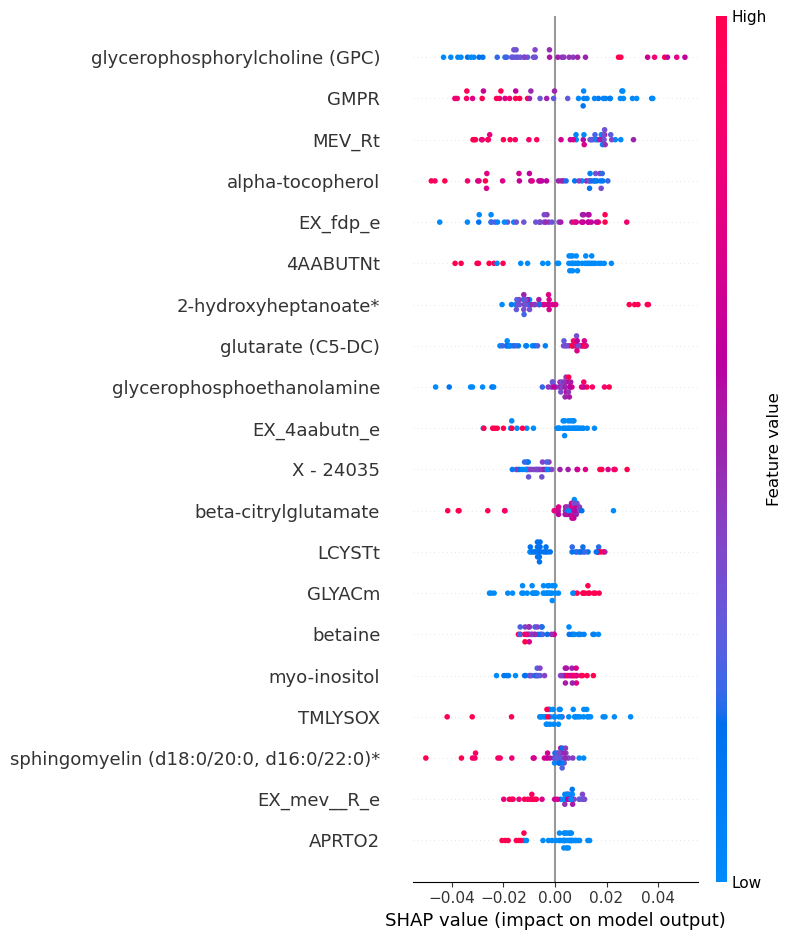

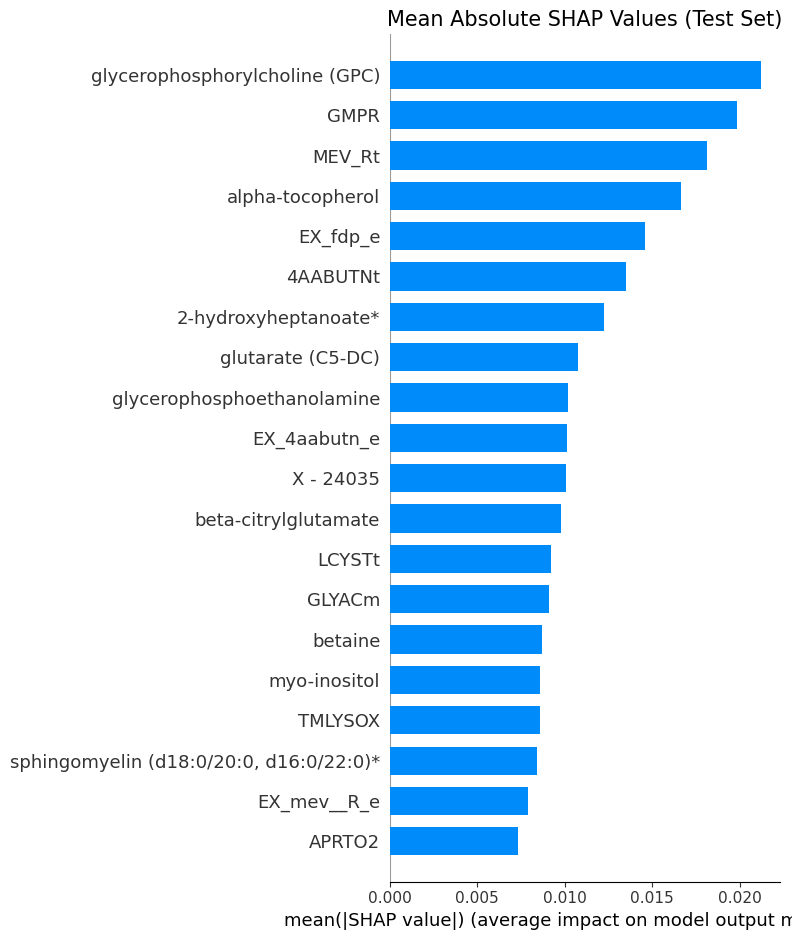


SHAP STRATEGIC FEATURE ANALYSIS REPORT (TEST SET)
                  Feature_Name  Average_Impact_Score
glycerophosphorylcholine (GPC)              0.021249
                          GMPR              0.019849
                        MEV_Rt              0.018142
              alpha-tocopherol              0.016650
                      EX_fdp_e              0.014564
                      4AABUTNt              0.013522
          2-hydroxyheptanoate*              0.012219
             glutarate (C5-DC)              0.010743
    glycerophosphoethanolamine              0.010169
                  EX_4aabutn_e              0.010146
                     X - 24035              0.010048
          beta-citrylglutamate              0.009793
                        LCYSTt              0.009194
                        GLYACm              0.009085
                       betaine              0.008722
Graphs saved as 'shap_summary_impact.png' and 'shap_feature_importance.png'


In [9]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 0. TRAIN / TEST SPLIT (minimal addition)
X_selected = X_train_scaled[:, selected_indices]

X_tr, X_te, y_tr, y_te = train_test_split(
    X_selected, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Convert to DataFrame for SHAP
X_train_df = pd.DataFrame(X_tr, columns=selected_features)
X_test_df  = pd.DataFrame(X_te, columns=selected_features)

# 1. Train model on TRAIN set only
rf_shap = RandomForestClassifier(n_estimators=100, random_state=42)
rf_shap.fit(X_train_df, y_tr)

# 2. Compute SHAP values on TEST set
explainer = shap.TreeExplainer(rf_shap)
shap_results = explainer.shap_values(X_test_df)

# Extract positive class SHAP values
if isinstance(shap_results, list):
    actual_shap_values = shap_results[1]
elif len(shap_results.shape) == 3:
    actual_shap_values = shap_results[:, :, 1]
else:
    actual_shap_values = shap_results

# 3A. Summary Plot (TEST DATA)
plt.figure(figsize=(12, 8))
shap.summary_plot(actual_shap_values, X_test_df, show=False)
plt.title("", fontsize=15)
plt.tight_layout()
plt.savefig('shap_summary_impact.png', dpi=300)
plt.show()

# 3B. Global Importance Bar Chart
plt.figure(figsize=(12, 8))
shap.summary_plot(actual_shap_values, X_test_df, plot_type="bar", show=False)
plt.title("Mean Absolute SHAP Values (Test Set)", fontsize=15)
plt.tight_layout()
plt.savefig('shap_feature_importance.png', dpi=300)
plt.show()

# 4. Written Report (TEST SET)
mean_shap_importance = np.abs(actual_shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    'Feature_Name': selected_features,
    'Average_Impact_Score': mean_shap_importance
}).sort_values(by='Average_Impact_Score', ascending=False)

print("\n" + "="*45)
print("SHAP STRATEGIC FEATURE ANALYSIS REPORT (TEST SET)")
print("="*45)
print(importance_df.head(15).to_string(index=False))
print("="*45)
print("Graphs saved as 'shap_summary_impact.png' and 'shap_feature_importance.png'")

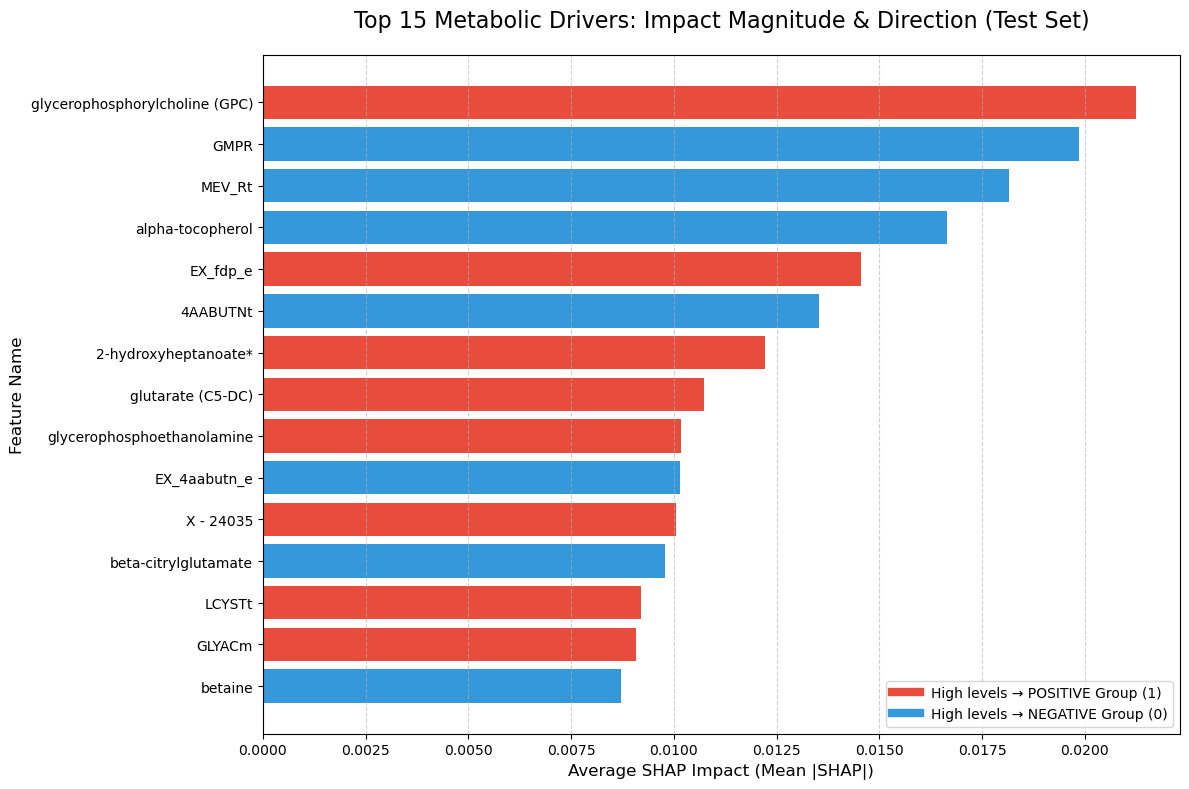


STRATEGIC BIOMARKER GROUP REPORT (TEST SET)
                       Feature           Group_Affiliation  Importance
glycerophosphorylcholine (GPC) Promotes POSITIVE Group (1)    0.021249
                          GMPR Promotes NEGATIVE Group (0)    0.019849
                        MEV_Rt Promotes NEGATIVE Group (0)    0.018142
              alpha-tocopherol Promotes NEGATIVE Group (0)    0.016650
                      EX_fdp_e Promotes POSITIVE Group (1)    0.014564
                      4AABUTNt Promotes NEGATIVE Group (0)    0.013522
          2-hydroxyheptanoate* Promotes POSITIVE Group (1)    0.012219
             glutarate (C5-DC) Promotes POSITIVE Group (1)    0.010743
    glycerophosphoethanolamine Promotes POSITIVE Group (1)    0.010169
                  EX_4aabutn_e Promotes NEGATIVE Group (0)    0.010146
                     X - 24035 Promotes POSITIVE Group (1)    0.010048
          beta-citrylglutamate Promotes NEGATIVE Group (0)    0.009793
                        LCYSTt P

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- CALCULATE FEATURE IMPACTS ON TEST SET ---
feature_impacts = []

for i, col in enumerate(selected_features):
    
    # Correlation between feature value and SHAP value
    corr_matrix = np.corrcoef(X_test_df[col], actual_shap_values[:, i])
    corr = corr_matrix[0, 1]
    
    # Handle possible NaN
    if np.isnan(corr):
        corr = 0

    # Mean absolute SHAP impact
    mean_impact = np.abs(actual_shap_values[:, i]).mean()
    
    # Determine direction of effect
    if corr > 0:
        direction = "Promotes POSITIVE Group (1)"
        color_code = "#e74c3c"  # Red
    else:
        direction = "Promotes NEGATIVE Group (0)"
        color_code = "#3498db"  # Blue
        
    feature_impacts.append({
        'Feature': col,
        'Importance': mean_impact,
        'Correlation': corr,
        'Group_Affiliation': direction,
        'Color': color_code
    })

# Create DataFrame and sort by importance
impact_df = pd.DataFrame(feature_impacts).sort_values(
    by='Importance', ascending=False
)

top15 = impact_df.head(15)

# --- PLOT: Group-Based Feature Importance (TEST SET) ---
plt.figure(figsize=(12, 8))

bars = plt.barh(
    top15['Feature'],
    top15['Importance'],
    color=top15['Color']
)

plt.gca().invert_yaxis()

plt.title('Top 15 Metabolic Drivers: Impact Magnitude & Direction (Test Set)', fontsize=16, pad=20)
plt.xlabel('Average SHAP Impact (Mean |SHAP|)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)

# Legend for color coding
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#e74c3c', lw=6, label='High levels → POSITIVE Group (1)'),
    Line2D([0], [0], color='#3498db', lw=6, label='High levels → NEGATIVE Group (0)')
]

plt.legend(handles=legend_elements, loc='lower right', frameon=True)

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('group_association_report.png', dpi=300)
plt.show()

# --- WRITTEN REPORT ---
print("\n" + "="*60)
print("STRATEGIC BIOMARKER GROUP REPORT (TEST SET)")
print("="*60)
print(top15[['Feature', 'Group_Affiliation', 'Importance']].to_string(index=False))
print("="*60)

In [11]:
import pandas as pd
import numpy as np
from scipy import stats

# --- SECTION 1: WELCH'S T-TEST (ON TEST SET) ---
# Use top 15 features from SHAP importance
top_features = importance_df.head(15)['Feature_Name'].tolist()

# Convert y_te to numpy array to avoid alignment issues
y_te_arr = np.array(y_te)

# Split test set into two groups (0: Control, 1: Positive)
group_0_data = X_test_df.iloc[y_te_arr == 0]
group_1_data = X_test_df.iloc[y_te_arr == 1]

ttest_results = []

for feat in top_features:
    # Welch's t-test: independent t-test assuming unequal variances
    t_stat, p_val = stats.ttest_ind(
        group_1_data[feat],
        group_0_data[feat],
        equal_var=False,
        nan_policy='omit'
    )
    
    # Handle NaN values
    if np.isnan(t_stat): t_stat = 0
    if np.isnan(p_val): p_val = 1.0

    ttest_results.append({
        'Feature': feat,
        'T-Statistic': round(t_stat, 4),
        'P-Value': f"{p_val:.4e}",
        'Significance (0.05)': '*' if p_val < 0.05 else 'ns',
        'Direction': 'Up-regulated' if t_stat > 0 else 'Down-regulated'
    })

ttest_final_df = pd.DataFrame(ttest_results)

# Sort t-test results by P-Value ascending
ttest_final_df['P-Value-Numeric'] = ttest_final_df['P-Value'].astype(float)
ttest_final_df = ttest_final_df.sort_values(by='P-Value-Numeric', ascending=True).drop(columns=['P-Value-Numeric'])

# --- SECTION 2: MCNEMAR TEST (ON TEST SET) ---
# Evaluate model error symmetry on unseen test data
y_pred = rf_shap.predict(X_test_df)

# Discordant pairs
b = np.sum((y_pred == 1) & (y_te_arr == 0))  # False Positives
c = np.sum((y_pred == 0) & (y_te_arr == 1))  # False Negatives

# McNemar statistic with Edwards correction
if (b + c) > 0:
    stat = (abs(b - c) - 1)**2 / (b + c)
    p_mcnemar = stats.chi2.sf(stat, 1)
else:
    stat, p_mcnemar = 0, 1.0

# --- PRINT FINAL REPORT ---
print("\n" + "="*85)
print("STATISTICAL REPORT: BIOMARKER SIGNIFICANCE & MODEL SYMMETRY (TEST SET)")
print("="*85)

print("\nWelch's T-Test Results (Top 15 Features, Sorted by P-Value):")
print(ttest_final_df.to_string(index=False))

print("\n" + "-"*40)
print("MCNEMAR TEST RESULTS (Test Set Error Symmetry)")
print(f"False Positives (b): {b}")
print(f"False Negatives (c): {c}")
print(f"Chi-Squared Stat: {stat:.4f}")
print(f"P-Value: {p_mcnemar:.4f}")
print("-" * 40)

if p_mcnemar < 0.05:
    print("RESULT: Significant bias in model errors on test set.")
else:
    print("RESULT: No significant bias. The model is balanced on unseen data.")
print("="*85)


STATISTICAL REPORT: BIOMARKER SIGNIFICANCE & MODEL SYMMETRY (TEST SET)

Welch's T-Test Results (Top 15 Features, Sorted by P-Value):
                       Feature  T-Statistic    P-Value Significance (0.05)      Direction
glycerophosphorylcholine (GPC)       3.3575 1.7979e-03                   *   Up-regulated
                        GLYACm       3.0896 3.9515e-03                   *   Up-regulated
                  EX_4aabutn_e      -3.2880 4.3411e-03                   * Down-regulated
                      4AABUTNt      -3.2880 4.3411e-03                   * Down-regulated
    glycerophosphoethanolamine       2.9647 5.3136e-03                   *   Up-regulated
                     X - 24035       2.5495 1.5114e-02                   *   Up-regulated
                       betaine      -2.5659 1.5437e-02                   * Down-regulated
                          GMPR      -2.2318 3.2724e-02                   * Down-regulated
          beta-citrylglutamate      -2.0442 4.8571e-02  

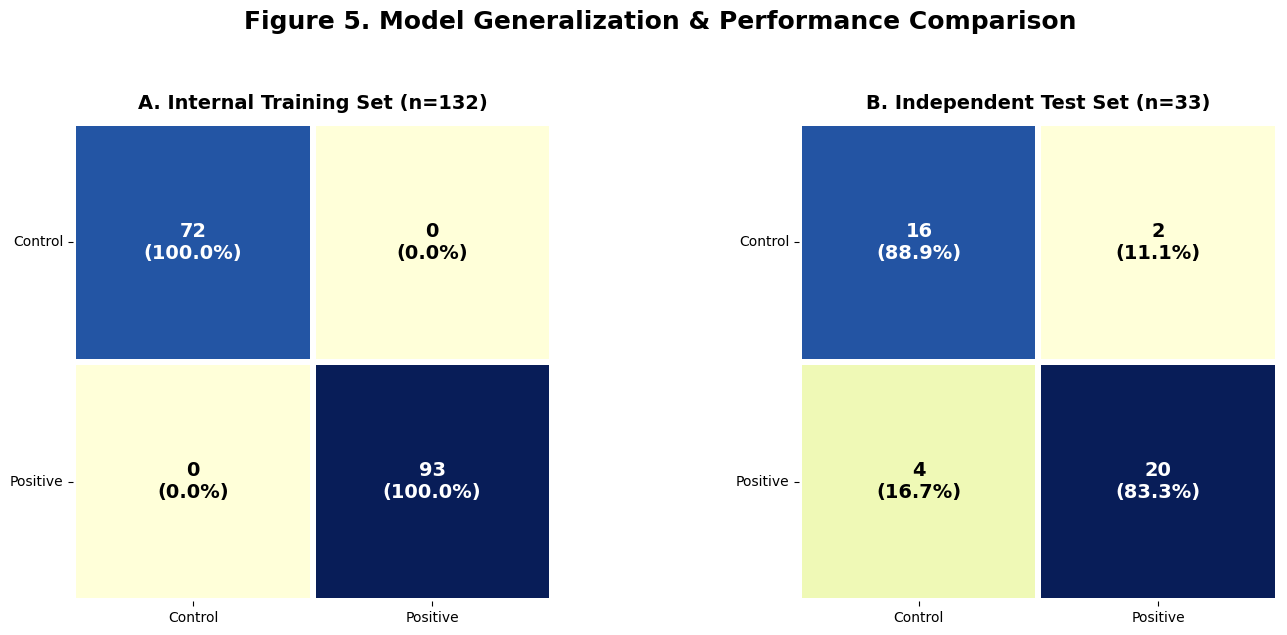

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# --- FUNCTION: Styled Confusion Matrix ---
def draw_styled_cm(data_true, data_pred, ax, title):
    """
    Draw a confusion matrix with counts and row-wise percentages.
    
    Parameters:
    - data_true: true labels
    - data_pred: predicted labels
    - ax: matplotlib axis object
    - title: subplot title
    """
    cm = confusion_matrix(data_true, data_pred)
    sns.heatmap(cm, annot=False, cmap="YlGnBu", cbar=False, 
                linewidths=3, linecolor='white', square=True, ax=ax)
    
    # Add counts and row-wise percentages inside squares
    for i in range(2):
        for j in range(2):
            count = cm[i, j]
            percent = (count / cm[i, :].sum()) * 100
            text = f"{count}\n({percent:.1f}%)"
            ax.text(j + 0.5, i + 0.5, text, ha="center", va="center", 
                    color="black" if percent < 70 else "white", fontsize=14, fontweight='bold')
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.set_xticklabels(['Control', 'Positive'])
    ax.set_yticklabels(['Control', 'Positive'], rotation=0)

# --- CREATE FIGURE: Training vs Test Performance ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left: Training Set Performance
y_train_pred = rf_shap.predict(X_train_df)
draw_styled_cm(y_tr, y_train_pred, ax1, "A. Internal Training Set (n=132)")

# Right: Test Set Performance
y_test_pred = rf_shap.predict(X_test_df)
draw_styled_cm(y_te_arr, y_test_pred, ax2, "B. Independent Test Set (n=33)")

# Overall figure title
plt.suptitle('Figure 5. Model Generalization & Performance Comparison', 
             fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('Train_vs_Test_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()